In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
X_train = sparse.load_npz("X_train_processed.npz")
X_test = sparse.load_npz("X_test_processed.npz")

y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

feature_names = np.load(
    "feature_names.npy",
    allow_pickle=True
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Number of feature names:", len(feature_names))

Training data shape: (13060, 402)
Testing data shape: (3124, 402)
Number of feature names: 402


In [ ]:
if X_train.shape[1] != len(feature_names):
    raise ValueError(
        "Number of feature names does not match "
        "number of processed features."
    )

print("Feature names successfully matched.")

Feature names successfully matched.


In [ ]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(linear_model.coef_),
    "Coefficient": linear_model.coef_
})

linear_importance = linear_importance.sort_values(
    "Importance",
    ascending=False
)

print("\nTop 15 Linear Regression Features:")
print(linear_importance.head(15))


Top 15 Linear Regression Features:
                                               Feature  Importance  \
400  categorical__Long-term health condition (LTHC)...   28.743792   
254        categorical__Language used at home_Kashmiri   17.516456   
15      categorical__Country of birth of person_Bhutan   15.134943   
299        categorical__Language used at home_Rohingya   13.393251   
246  categorical__Language used at home_Indo-Aryan,...   11.421539   
243            categorical__Language used at home_Igbo   10.401789   
268         categorical__Language used at home_Luganda   10.029485   
308  categorical__Language used at home_Sign Langua...    9.878823   
327         categorical__Language used at home_Tibetan    9.718288   
128  categorical__Country of birth of person_Samoa,...    9.712420   
157     categorical__Country of birth of person_Tuvalu    9.512560   
337        categorical__Language used at home_Tuvaluan    9.512560   
393  categorical__Long-term health condition (LTHC)...

In [ ]:
dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model.feature_importances_
})

dt_importance = dt_importance.sort_values(
    "Importance",
    ascending=False
)

print("\nTop 15 Decision Tree Features:")
print(dt_importance.head(15))


Top 15 Decision Tree Features:
                                               Feature  Importance
400  categorical__Long-term health condition (LTHC)...    0.458993
176                 categorical__Age group_65 and over    0.300922
175                       categorical__Age group_45–64    0.052260
390  categorical__Long-term health condition (LTHC)...    0.022862
394  categorical__Long-term health condition (LTHC)...    0.022231
389  categorical__Long-term health condition (LTHC)...    0.016240
171   categorical__Years spent in Australia_0–10 years    0.013284
396  categorical__Long-term health condition (LTHC)...    0.010832
174                       categorical__Age group_00–44    0.010219
354          categorical__Region_class_North-East Asia    0.009636
395  categorical__Long-term health condition (LTHC)...    0.008467
350  categorical__Proficiency in spoken English_Not...    0.006797
192          categorical__Language used at home_Auslan    0.005424
383         categorical__Subre

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

print("\nTop 15 Random Forest Features:")
print(rf_importance.head(15))


Top 15 Random Forest Features:
                                               Feature  Importance
400  categorical__Long-term health condition (LTHC)...    0.441460
176                 categorical__Age group_65 and over    0.289777
175                       categorical__Age group_45–64    0.032250
174                       categorical__Age group_00–44    0.027988
394  categorical__Long-term health condition (LTHC)...    0.023077
390  categorical__Long-term health condition (LTHC)...    0.020611
389  categorical__Long-term health condition (LTHC)...    0.015793
171   categorical__Years spent in Australia_0–10 years    0.013747
396  categorical__Long-term health condition (LTHC)...    0.010438
354          categorical__Region_class_North-East Asia    0.009443
395  categorical__Long-term health condition (LTHC)...    0.008129
350  categorical__Proficiency in spoken English_Not...    0.007291
192          categorical__Language used at home_Auslan    0.005532
383         categorical__Subre

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)

print("\nTop 15 XGBoost Features:")
print(xgb_importance.head(15))


Top 15 XGBoost Features:
                                               Feature  Importance
400  categorical__Long-term health condition (LTHC)...    0.274751
176                 categorical__Age group_65 and over    0.252734
390  categorical__Long-term health condition (LTHC)...    0.029432
174                       categorical__Age group_00–44    0.019505
396  categorical__Long-term health condition (LTHC)...    0.017491
394  categorical__Long-term health condition (LTHC)...    0.017431
383         categorical__Subregion_class_Southern Asia    0.015664
192          categorical__Language used at home_Auslan    0.013906
308  categorical__Language used at home_Sign Langua...    0.012926
401  categorical__Long-term health condition (LTHC)...    0.011803
389  categorical__Long-term health condition (LTHC)...    0.011056
3    categorical__Country of birth of person_Americ...    0.009793
171   categorical__Years spent in Australia_0–10 years    0.008946
395  categorical__Long-term health c

In [ ]:
def plot_feature_importance(
    importance_df,
    title
):

    top_features = (
        importance_df
        .head(15)
        .sort_values("Importance")
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(title)

    plt.tight_layout()
    plt.show()

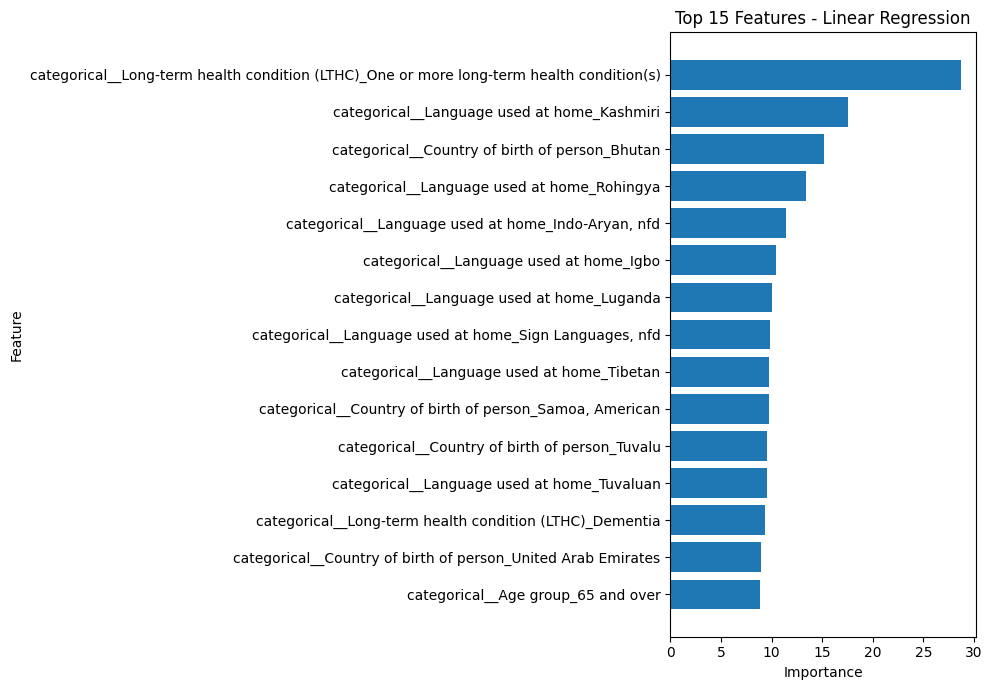

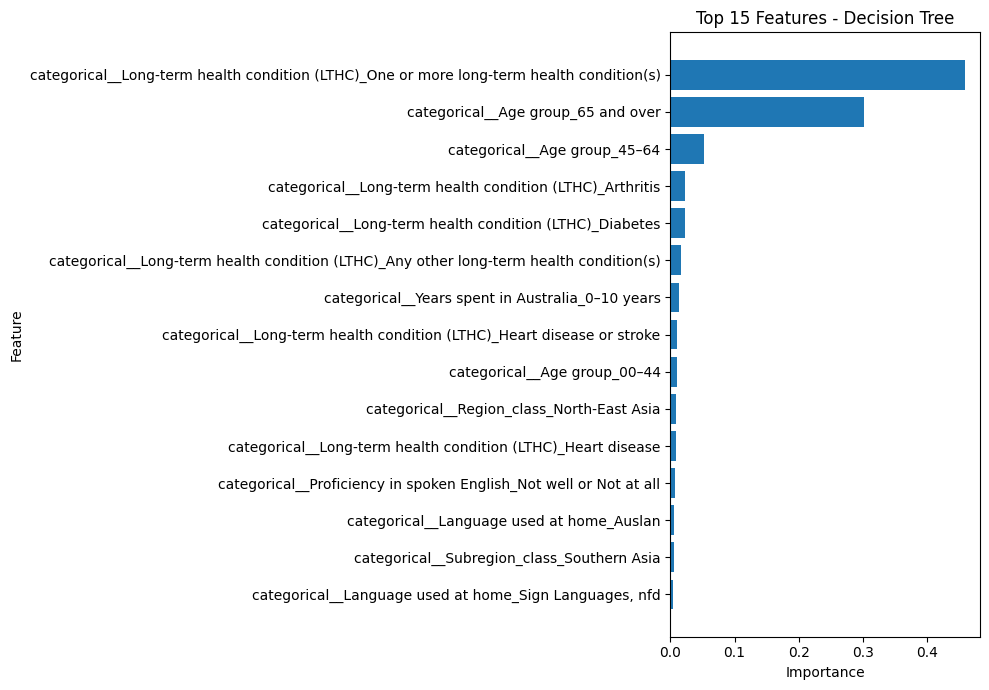

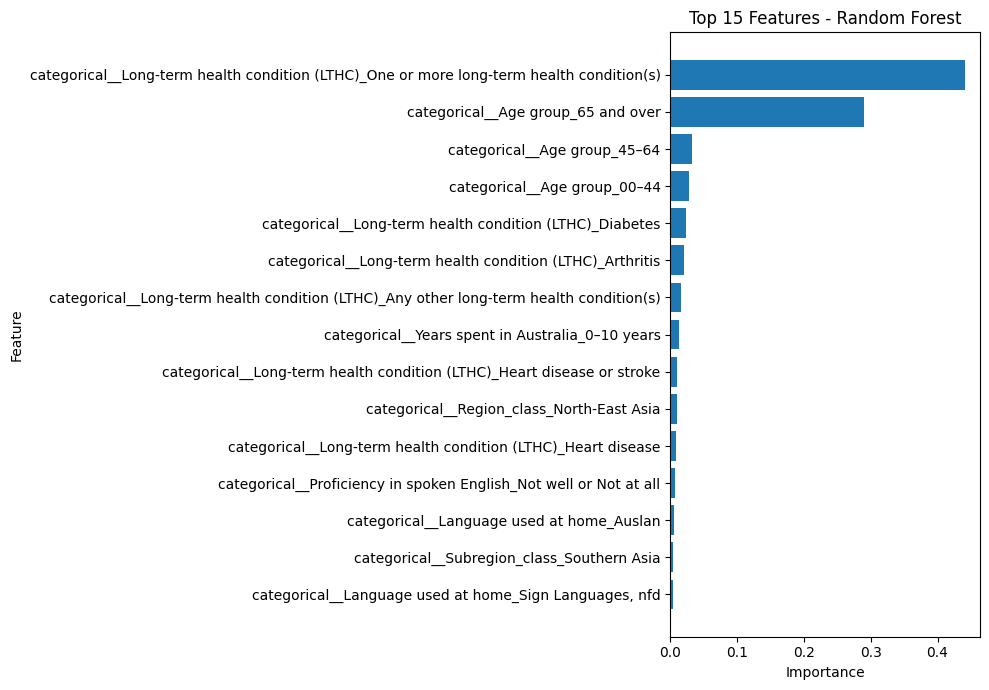

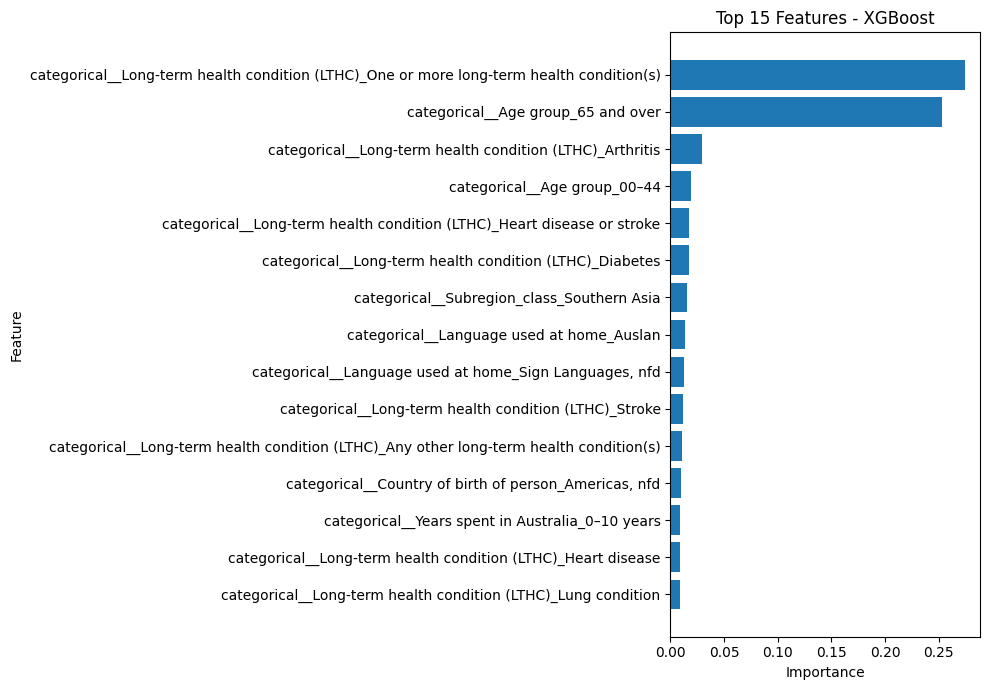

In [ ]:
plot_feature_importance(
    linear_importance,
    "Top 15 Features - Linear Regression"
)

plot_feature_importance(
    dt_importance,
    "Top 15 Features - Decision Tree"
)

plot_feature_importance(
    rf_importance,
    "Top 15 Features - Random Forest"
)

plot_feature_importance(
    xgb_importance,
    "Top 15 Features - XGBoost"
)

In [ ]:
linear_importance.to_csv(
    "linear_feature_importance.csv",
    index=False
)

dt_importance.to_csv(
    "decision_tree_feature_importance.csv",
    index=False
)

rf_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

xgb_importance.to_csv(
    "xgboost_feature_importance.csv",
    index=False
)

print("\nFeature importance results saved successfully.")


Feature importance results saved successfully.
